<a href="https://colab.research.google.com/github/ACRivera1/data-quality-engine/blob/main/referral_program_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 User Referral Program Analysis
## Company XYZ — Evaluating the $10 Credit Referral Program

---

### 🎯 Project Context
Company XYZ launched a referral program on **October 31, 2015**. When an existing user successfully refers a new user, and that new user makes a purchase, the referrer earns **\$10 in credit**.

This notebook analyzes **97,341 real transactions** from October 3 – November 27, 2015, answering:

1. How has user growth changed since the program launched?
2. What share of transactions are driven by referrals?
3. Do referred users spend more or less than non-referred users?
4. Which countries show the highest referral activity?
5. What are the program's limitations and recommended next steps?

---

## 📦 STEP 1: Install Required Libraries

Run this cell **first and only once**. The `!` at the start tells Jupyter to run the command in the terminal.

| Library | What it does |
|---|---|
| **pandas** | Load, clean, and manipulate tabular data (like Excel but in Python) |
| **numpy** | Math and numerical operations |
| **matplotlib** | Create charts and graphs |
| **seaborn** | Prettier charts built on top of matplotlib |
| **scipy** | Statistical tests (tells us if findings are real, not random) |
| **openpyxl** | Lets pandas read/write Excel `.xlsx` files |

In [1]:
# Install all libraries in one command
# If they are already installed, pip will skip them -- safe to re-run
!pip install pandas numpy matplotlib seaborn scipy openpyxl

## 📥 STEP 2: Import Libraries

Installing puts the tools on your computer. **Importing** loads them into your current Python session so you can actually use them.

In [2]:
# pandas -- the core data library; 'pd' is the standard shorthand alias
import pandas as pd

# numpy -- numerical computing; 'np' is the standard shorthand
import numpy as np

# matplotlib.pyplot -- the main plotting module; 'plt' is the standard shorthand
import matplotlib.pyplot as plt

# matplotlib.dates -- helps format date values on chart axes
import matplotlib.dates as mdates

# seaborn -- statistical visualization library; 'sns' is the standard shorthand
import seaborn as sns

# scipy.stats -- statistical functions like t-tests
from scipy import stats

# warnings -- lets us suppress harmless warning messages for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Tell Jupyter to display charts directly inside the notebook
%matplotlib inline

# Set a clean, professional chart style
sns.set_style('whitegrid')

# Default figure size: 12 inches wide, 5 inches tall
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# Define a consistent color palette we will reuse throughout the notebook
COLORS = {
    'referral':     '#2ecc71',   # Green  -- referred users
    'non_referral': '#3498db',   # Blue   -- non-referred users
    'before':       '#e74c3c',   # Red    -- pre-launch period
    'after':        '#9b59b6',   # Purple -- post-launch period
}

print('All libraries imported successfully!')

All libraries imported successfully!


## 📂 STEP 3: Load the Data

Place `referral.csv` in the **same folder** as this notebook, then run the cell below.

`pd.read_csv()` reads the file and stores it as a **DataFrame** -- Python's version of a spreadsheet.

In [3]:
# Load the CSV file into a DataFrame called df
# Make sure referral.csv is in the same folder as this notebook!
df = pd.read_csv('referral.csv')

# Convert the date column from plain text to a real datetime object
# This lets us do date math: comparisons, grouping by week, calculating differences, etc.
df['date'] = pd.to_datetime(df['date'])

# Define the program launch date -- we will compare everything relative to this
LAUNCH_DATE = pd.to_datetime('2015-10-31')

print('Data loaded successfully!')
print(f'   Total rows (transactions): {len(df):,}')
print(f'   Columns: {list(df.columns)}')
print(f'   Date range: {df["date"].min().date()} to {df["date"].max().date()}')

Data loaded successfully!
   Total rows (transactions): 97,341
   Columns: ['user_id', 'date', 'country', 'money_spent', 'is_referral', 'device_id']
   Date range: 2015-10-03 to 2015-11-27


## 🔍 STEP 4: Exploratory Data Analysis (EDA)

Before any analysis, we always **explore** the data first. This step reveals the structure, catches missing values, and prevents costly mistakes later.

In [4]:
# .head() shows the first N rows -- a quick visual sanity check
print('First 8 rows of the dataset:')
df.head(8)

First 8 rows of the dataset:


,user_id,date,country,money_spent,is_referral,device_id
0,2,2015-10-03,FR,65,0,EVDCJTZMVMJDG
1,3,2015-10-03,CA,54,0,WUBZFTVKXGQQX
2,6,2015-10-03,FR,35,0,CBAPCJRTFNUJG
3,7,2015-10-03,UK,73,0,PRGXJZAJKMXRH
4,7,2015-10-03,MX,35,0,PRGXJZAJKMXRH
5,10,2015-10-03,DE,36,0,CVZCQLPXZCFUV
6,17,2015-10-03,UK,25,0,RCHOYRWHPOEVE
7,19,2015-10-03,UK,69,0,ICGUPKJIJFZUK


In [5]:
print('=' * 55)
print('DATASET OVERVIEW')
print('=' * 55)

# .shape returns (number of rows, number of columns)
print(f'Shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns')

# .dtypes shows the data type Python assigned to each column
# object = text string, int64 = integer, float64 = decimal number
print('\nColumn Data Types:')
print(df.dtypes)

# .isnull().sum() counts how many values are missing (NaN) per column
# Missing data can skew results, so we always check this first
print('\nMissing Values Per Column:')
missing = df.isnull().sum()
print(missing)
if missing.sum() == 0:
    print('   No missing values found!')

# .describe() gives count, mean, std, min, 25th/50th/75th percentile, and max
# for all numeric columns -- an instant statistical summary
print('\nStatistical Summary (numeric columns):')
print(df.describe().round(2))

DATASET OVERVIEW
Shape: 97,341 rows  x  6 columns

Column Data Types:
user_id                 int64
date           datetime64[ns]
country                object
money_spent             int64
is_referral             int64
device_id              object
dtype: object

Missing Values Per Column:
user_id        0
date           0
country        0
money_spent    0
is_referral    0
device_id      0
dtype: int64
   No missing values found!

Statistical Summary (numeric columns):
        user_id                           date  money_spent  is_referral
count  97341.00                          97341     97341.00     97341.00
mean    6354.80  2015-10-30 02:52:35.644589568        44.69         0.29
min        1.00            2015-10-03 00:00:00        10.00         0.00
25%     2020.00            2015-10-17 00:00:00        27.00         0.00
50%     4053.00            2015-10-31 00:00:00        42.00         0.00
75%    10286.00            2015-11-14 00:00:00        59.00         1.00
max    20000.0

In [6]:
# Understand the categorical columns

# .value_counts() counts how many times each unique value appears in a column
print('is_referral breakdown (0 = not referred, 1 = referred):')
print(df['is_referral'].value_counts())
print(f'  Referral share of ALL transactions: {df["is_referral"].mean()*100:.1f}%\n')

print('Countries in the dataset:')
print(df['country'].value_counts())

# Check if the same user can appear multiple times (multiple purchases)
total_rows   = len(df)
unique_users = df['user_id'].nunique()  # .nunique() = count of unique values
print(f'\nTotal transactions : {total_rows:,}')
print(f'Unique users       : {unique_users:,}')
print(f'Avg transactions per user: {total_rows/unique_users:.2f}')
print('Users can have multiple transactions -- the same user_id may appear many times.')

is_referral breakdown (0 = not referred, 1 = referred):
is_referral
0    69324
1    28017
Name: count, dtype: int64
  Referral share of ALL transactions: 28.8%

Countries in the dataset:
country
UK    15493
FR    15396
US    15280
IT    11446
DE    11093
ES     9831
CA     9440
MX     8133
CH     1229
Name: count, dtype: int64

Total transactions : 97,341
Unique users       : 18,809
Avg transactions per user: 5.18
Users can have multiple transactions -- the same user_id may appear many times.


## 🛠️ STEP 5: Feature Engineering

We create new columns derived from existing data to make the analysis easier and more readable.

In [7]:
# 1. 'period' column: label every transaction as Before or After the program launch
#    np.where() works like Excel IF(): if condition is True -> first value, else -> second value
df['period'] = np.where(df['date'] < LAUNCH_DATE, 'Before Program', 'After Program')

# 2. 'referral_label' column: human-readable version of the 1/0 is_referral column
#    .map() replaces each key in the column with its matching dictionary value
df['referral_label'] = df['is_referral'].map({1: 'Referred', 0: 'Non-Referred'})

# 3. 'week' column: group each date into its calendar week for weekly trend charts
#    .dt.to_period('W') converts a date to the weekly period it belongs to
#    .dt.start_time converts that period back to a datetime (the Monday of that week)
df['week'] = df['date'].dt.to_period('W').dt.start_time

# Verify the new columns look correct
print('Period breakdown:')
print(df['period'].value_counts())
print('\nReferral label check:')
print(df['referral_label'].value_counts())
print('\nNew columns added: period, referral_label, week')

Period breakdown:
period
After Program     50000
Before Program    47341
Name: count, dtype: int64

Referral label check:
referral_label
Non-Referred    69324
Referred        28017
Name: count, dtype: int64

New columns added: period, referral_label, week


---
## 📈 ANALYSIS 1: User Growth — Before vs. After Launch

**Question: Did the referral program drive an increase in daily activity?**

We compare the 28 days before launch (Oct 3-30) vs. the 28 days after (Oct 31-Nov 27).

In [8]:
# Compute daily transaction counts and unique user counts
# .groupby('date') groups all rows that share the same date into one bucket
# .agg() applies multiple aggregation functions at once:
#   'count' counts total rows in each group (= transactions per day)
#   'nunique' counts unique user_ids per group (= distinct users per day)
daily = df.groupby('date').agg(
    transactions = ('user_id', 'count'),
    unique_users = ('user_id', 'nunique')
).reset_index()  # reset_index() turns the group key back into a regular column

# Split into before and after launch periods
daily_before = daily[daily['date'] < LAUNCH_DATE]
daily_after  = daily[daily['date'] >= LAUNCH_DATE]

# Calculate the average for each period
avg_txn_before  = daily_before['transactions'].mean()
avg_txn_after   = daily_after['transactions'].mean()
avg_user_before = daily_before['unique_users'].mean()
avg_user_after  = daily_after['unique_users'].mean()

# Percentage change formula: ((new - old) / old) * 100
txn_growth  = (avg_txn_after  - avg_txn_before)  / avg_txn_before  * 100
user_growth = (avg_user_after - avg_user_before) / avg_user_before * 100

print('DAILY ACTIVITY: BEFORE vs. AFTER LAUNCH')
print('-' * 48)
print(f'{"Metric":<35} {"Before":>7} {"After":>7} {"Change":>8}')
print('-' * 48)
print(f'{"Avg Daily Transactions":<35} {avg_txn_before:>7.0f} {avg_txn_after:>7.0f} {txn_growth:>+7.1f}%')
print(f'{"Avg Daily Unique Users":<35} {avg_user_before:>7.0f} {avg_user_after:>7.0f} {user_growth:>+7.1f}%')

DAILY ACTIVITY: BEFORE vs. AFTER LAUNCH
------------------------------------------------
Metric                               Before   After   Change
------------------------------------------------
Avg Daily Transactions                 1691    1786    +5.6%
Avg Daily Unique Users                 1384    1687   +21.8%


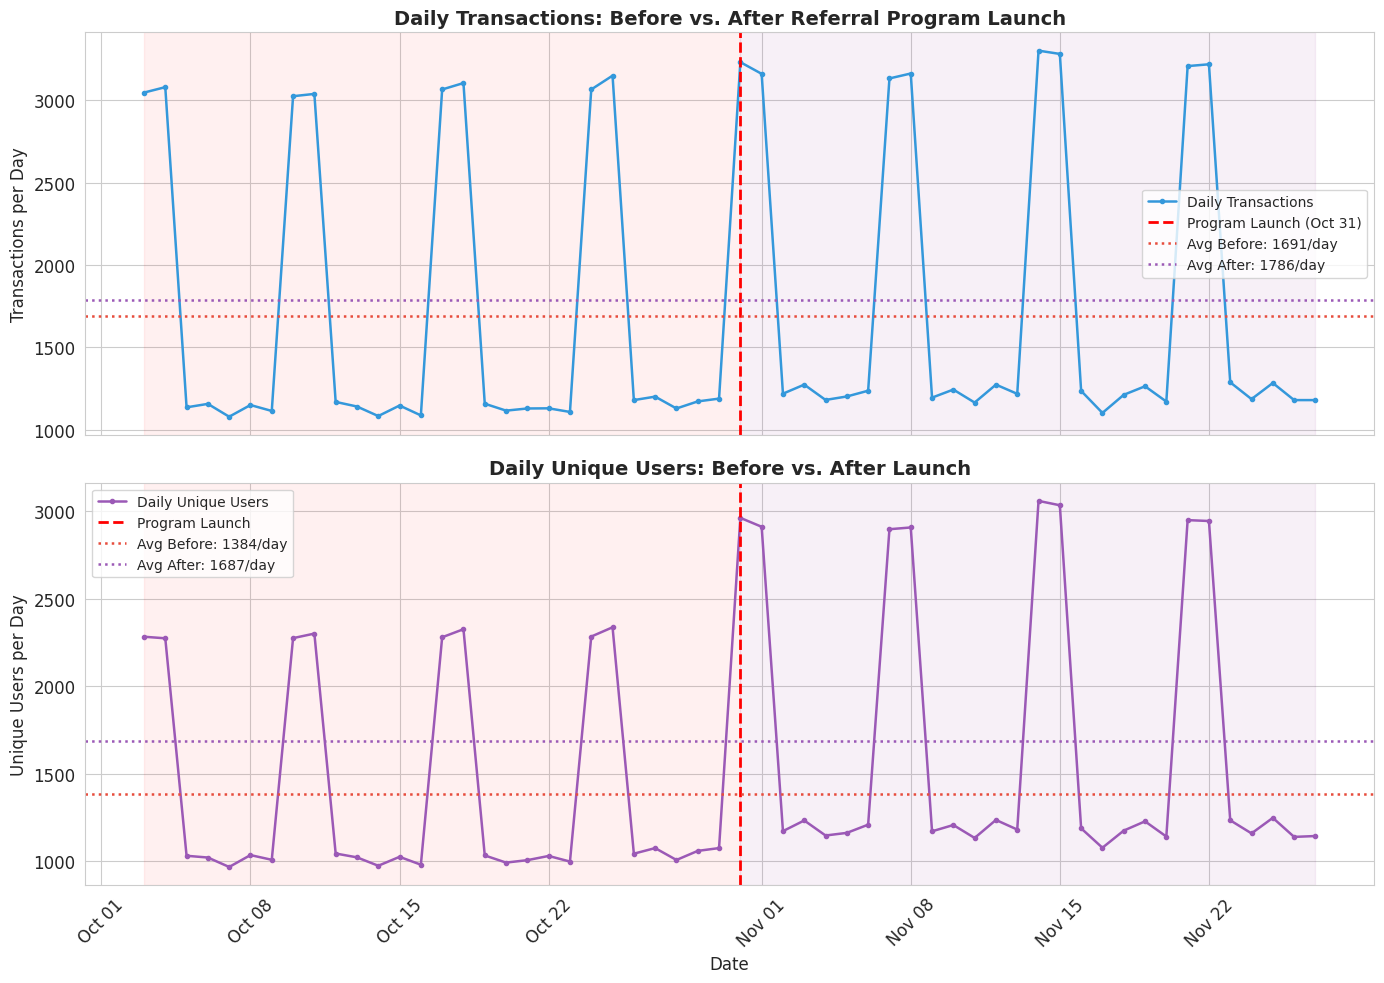

INSIGHT: After launch, avg daily transactions rose from 1691 to 1786 (+5.6%).
         Unique daily users jumped from 1384 to 1687 (+21.8%).


In [9]:
# Visualize daily transaction and unique user trends
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# TOP CHART: Daily Transactions
ax1.plot(daily['date'], daily['transactions'],
         color='#3498db', linewidth=1.8, marker='o', markersize=3, label='Daily Transactions')

# axvline() draws a vertical line at a specific x value -- used to mark the launch date
ax1.axvline(x=LAUNCH_DATE, color='red', linestyle='--', linewidth=2, label='Program Launch (Oct 31)')

# axhline() draws a horizontal reference line across the whole chart
ax1.axhline(y=avg_txn_before, color=COLORS['before'], linestyle=':', linewidth=1.8,
            label=f'Avg Before: {avg_txn_before:.0f}/day')
ax1.axhline(y=avg_txn_after,  color=COLORS['after'],  linestyle=':', linewidth=1.8,
            label=f'Avg After: {avg_txn_after:.0f}/day')

# axvspan() fills a vertical band between two x-values with a shaded background
ax1.axvspan(daily['date'].min(), LAUNCH_DATE, alpha=0.06, color='red')
ax1.axvspan(LAUNCH_DATE, daily['date'].max(), alpha=0.06, color='purple')

ax1.set_title('Daily Transactions: Before vs. After Referral Program Launch', fontsize=14, fontweight='bold')
ax1.set_ylabel('Transactions per Day')
ax1.legend(fontsize=10)

# BOTTOM CHART: Daily Unique Users
ax2.plot(daily['date'], daily['unique_users'],
         color='#9b59b6', linewidth=1.8, marker='o', markersize=3, label='Daily Unique Users')
ax2.axvline(x=LAUNCH_DATE, color='red', linestyle='--', linewidth=2, label='Program Launch')
ax2.axhline(y=avg_user_before, color=COLORS['before'], linestyle=':', linewidth=1.8,
            label=f'Avg Before: {avg_user_before:.0f}/day')
ax2.axhline(y=avg_user_after,  color=COLORS['after'],  linestyle=':', linewidth=1.8,
            label=f'Avg After: {avg_user_after:.0f}/day')
ax2.axvspan(daily['date'].min(), LAUNCH_DATE, alpha=0.06, color='red')
ax2.axvspan(LAUNCH_DATE, daily['date'].max(), alpha=0.06, color='purple')

ax2.set_title('Daily Unique Users: Before vs. After Launch', fontsize=14, fontweight='bold')
ax2.set_ylabel('Unique Users per Day')
ax2.set_xlabel('Date')
ax2.legend(fontsize=10)

# Format x-axis to show readable month/day labels
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('chart1_growth_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'INSIGHT: After launch, avg daily transactions rose from {avg_txn_before:.0f} to {avg_txn_after:.0f} ({txn_growth:+.1f}%).')
print(f'         Unique daily users jumped from {avg_user_before:.0f} to {avg_user_after:.0f} ({user_growth:+.1f}%).')

---
## 📊 ANALYSIS 2: Referral vs. Non-Referral Transaction Share

**Question: What percentage of post-launch transactions came from referred users?**

In [10]:
# Filter to post-launch data only (referrals only exist on/after Oct 31)
# Boolean indexing: df[condition] returns only rows where the condition is True
post = df[df['period'] == 'After Program'].copy()

# Count transactions by user type
# .value_counts() returns each unique value and how many times it appears
ref_counts = post['referral_label'].value_counts()

# Calculate percentage share
ref_pct = (ref_counts / ref_counts.sum() * 100).round(1)

print('Post-Launch Transaction Breakdown:')
for label in ref_counts.index:
    print(f'  {label:<16}: {ref_counts[label]:>6,}  ({ref_pct[label]}%)')
print(f'  {"TOTAL":<16}: {ref_counts.sum():>6,}  (100%)')

# Weekly referral share trend -- is the share growing or stable over time?
# Group by week AND referral_label, count rows in each combination
weekly = post.groupby(['week', 'referral_label']).size().reset_index(name='count')

# .pivot() reshapes the data:
#   Each week becomes a row
#   Each referral_label value becomes its own column
#   The cell values are the counts
weekly_piv = weekly.pivot(index='week', columns='referral_label', values='count').fillna(0)

# Calculate referral share per week
weekly_piv['total'] = weekly_piv.sum(axis=1)  # Sum across all columns for each row
weekly_piv['referral_share_pct'] = (weekly_piv['Referred'] / weekly_piv['total'] * 100).round(1)

print('\nWeekly Referral Share (Post-Launch):')
print(weekly_piv[['Referred', 'Non-Referred', 'total', 'referral_share_pct']].to_string())

Post-Launch Transaction Breakdown:
  Referred        : 28,017  (56.0%)
  Non-Referred    : 21,983  (44.0%)
  TOTAL           : 50,000  (100%)

Weekly Referral Share (Post-Launch):
referral_label  Referred  Non-Referred  total  referral_share_pct
week                                                             
2015-10-26          3559          2836   6395                55.7
2015-11-02          6971          5435  12406                56.2
2015-11-09          7150          5527  12677                56.4
2015-11-16          6866          5543  12409                55.3
2015-11-23          3471          2642   6113                56.8


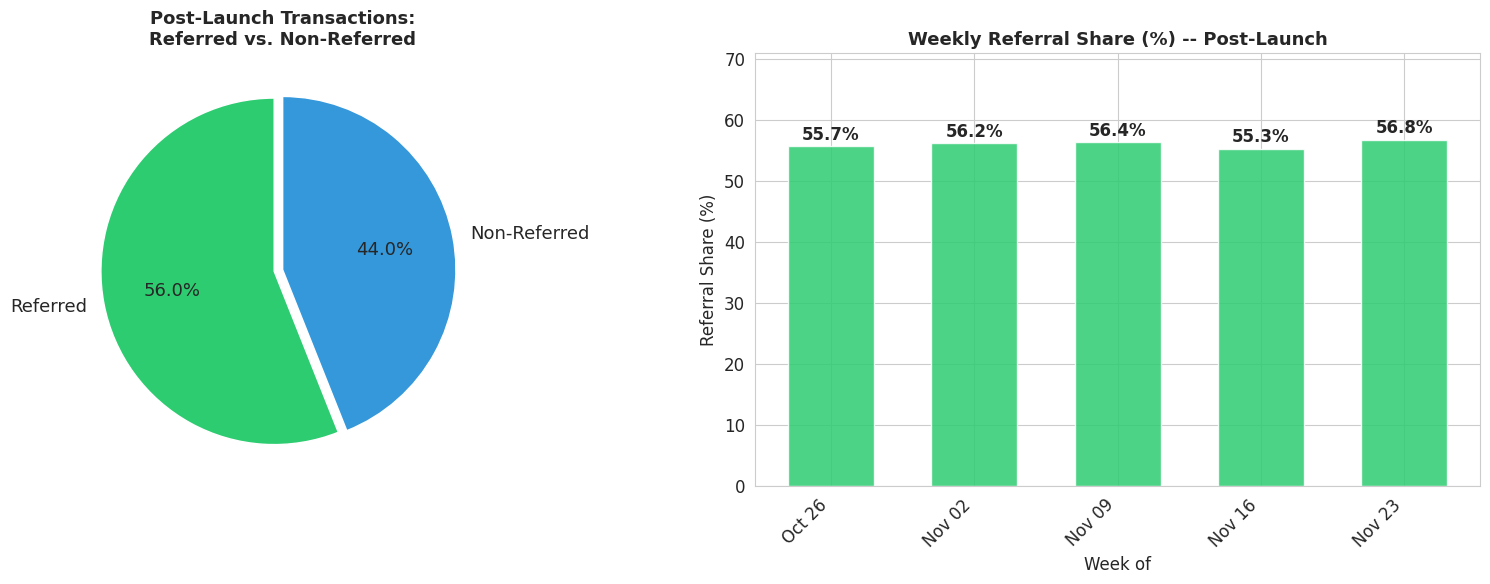

INSIGHT: 56.0% of all post-launch transactions came from the referral program.


In [11]:
# Visualize referral share
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Pie chart -- overall referral vs. non-referral share
ax1.pie(
    ref_counts.values,
    labels=ref_counts.index,
    autopct='%1.1f%%',        # Show percentages with 1 decimal place inside each slice
    colors=[COLORS['referral'], COLORS['non_referral']],
    startangle=90,             # Start first slice at 12 o'clock position
    explode=(0.05, 0),         # Pull the first slice out slightly for visual emphasis
    textprops={'fontsize': 13}
)
ax1.set_title('Post-Launch Transactions:\nReferred vs. Non-Referred', fontsize=13, fontweight='bold')

# RIGHT: Bar chart -- weekly referral share trend
x_positions = range(len(weekly_piv))
bars = ax2.bar(x_positions, weekly_piv['referral_share_pct'],
               color=COLORS['referral'], alpha=0.85, edgecolor='white', width=0.6)

# Add a percentage label on top of each bar
for bar in bars:
    height = bar.get_height()
    # .text() places a text annotation at (x, y)
    # ha='center' = horizontal alignment; va='bottom' = vertical alignment
    ax2.text(bar.get_x() + bar.get_width() / 2,
             height + 0.4,
             f'{height:.1f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=12)

# Set x-axis tick labels to the week start dates
week_labels = [w.strftime('%b %d') for w in weekly_piv.index]
ax2.set_xticks(x_positions)
ax2.set_xticklabels(week_labels, rotation=45, ha='right')
ax2.set_title('Weekly Referral Share (%) -- Post-Launch', fontsize=13, fontweight='bold')
ax2.set_xlabel('Week of')
ax2.set_ylabel('Referral Share (%)')
ax2.set_ylim(0, weekly_piv['referral_share_pct'].max() * 1.25)

plt.tight_layout()
plt.savefig('chart2_referral_share.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'INSIGHT: {ref_pct["Referred"]}% of all post-launch transactions came from the referral program.')

---
## 💵 ANALYSIS 3: Spending — Referred vs. Non-Referred Users

**Question: Do referred users spend more? Is the difference statistically significant?**

We use an **independent t-test** to find out whether any spending difference is real or just random chance.

In [12]:
# Compute spending summary statistics by user type
# .agg() with named outputs: column_name=('source_column', 'aggregation_function')
spending_summary = post.groupby('referral_label')['money_spent'].agg(
    Count         = 'count',
    Mean          = 'mean',
    Median        = 'median',
    Std_Dev       = 'std',
    Total_Revenue = 'sum'
).round(2)

print('Spending Summary by User Type (Post-Launch):')
print(spending_summary.to_string())

# Statistical Significance Test
# An independent samples t-test compares the means of two separate groups.
# It tells us: could this spending difference have happened by random chance?
#   t_stat: how many standard errors apart the two means are
#   p_value: probability of seeing this difference purely by random chance
#     p < 0.05 means statistically significant (we trust the difference is real)
#     p >= 0.05 means not significant (could easily be random noise)
referred_spend     = post[post['is_referral'] == 1]['money_spent']
non_referred_spend = post[post['is_referral'] == 0]['money_spent']

t_stat, p_value = stats.ttest_ind(referred_spend, non_referred_spend)

print(f'\nIndependent T-Test:')
print(f'   t-statistic: {t_stat:.4f}')
print(f'   p-value    : {p_value:.4f}')
if p_value < 0.05:
    print('   STATISTICALLY SIGNIFICANT -- the spending difference is real, not random.')
else:
    print('   NOT statistically significant -- the difference could be due to chance.')

# Revenue Impact Calculation
n_referrals          = int(post['is_referral'].sum())
referral_revenue     = referred_spend.sum()
program_credit_cost  = n_referrals * 10   # $10 credit per successful referral
net_referral_revenue = referral_revenue - program_credit_cost

print(f'\nREVENUE IMPACT (Post-Launch):')
print(f'   Referral transactions       : {n_referrals:>8,}')
print(f'   Gross revenue from referrals: ${referral_revenue:>10,.2f}')
print(f'   Credit costs ($10 x {n_referrals:,})  : ${program_credit_cost:>10,.2f}')
print(f'   Net revenue from referrals  : ${net_referral_revenue:>10,.2f}')

Spending Summary by User Type (Post-Launch):
                Count   Mean  Median  Std_Dev  Total_Revenue
referral_label                                              
Non-Referred    21983  46.77    43.0    24.46        1028216
Referred        28017  46.96    44.0    24.40        1315787

Independent T-Test:
   t-statistic: 0.8663
   p-value    : 0.3863
   NOT statistically significant -- the difference could be due to chance.

REVENUE IMPACT (Post-Launch):
   Referral transactions       :   28,017
   Gross revenue from referrals: $1,315,787.00
   Credit costs ($10 x 28,017)  : $280,170.00
   Net revenue from referrals  : $1,035,617.00


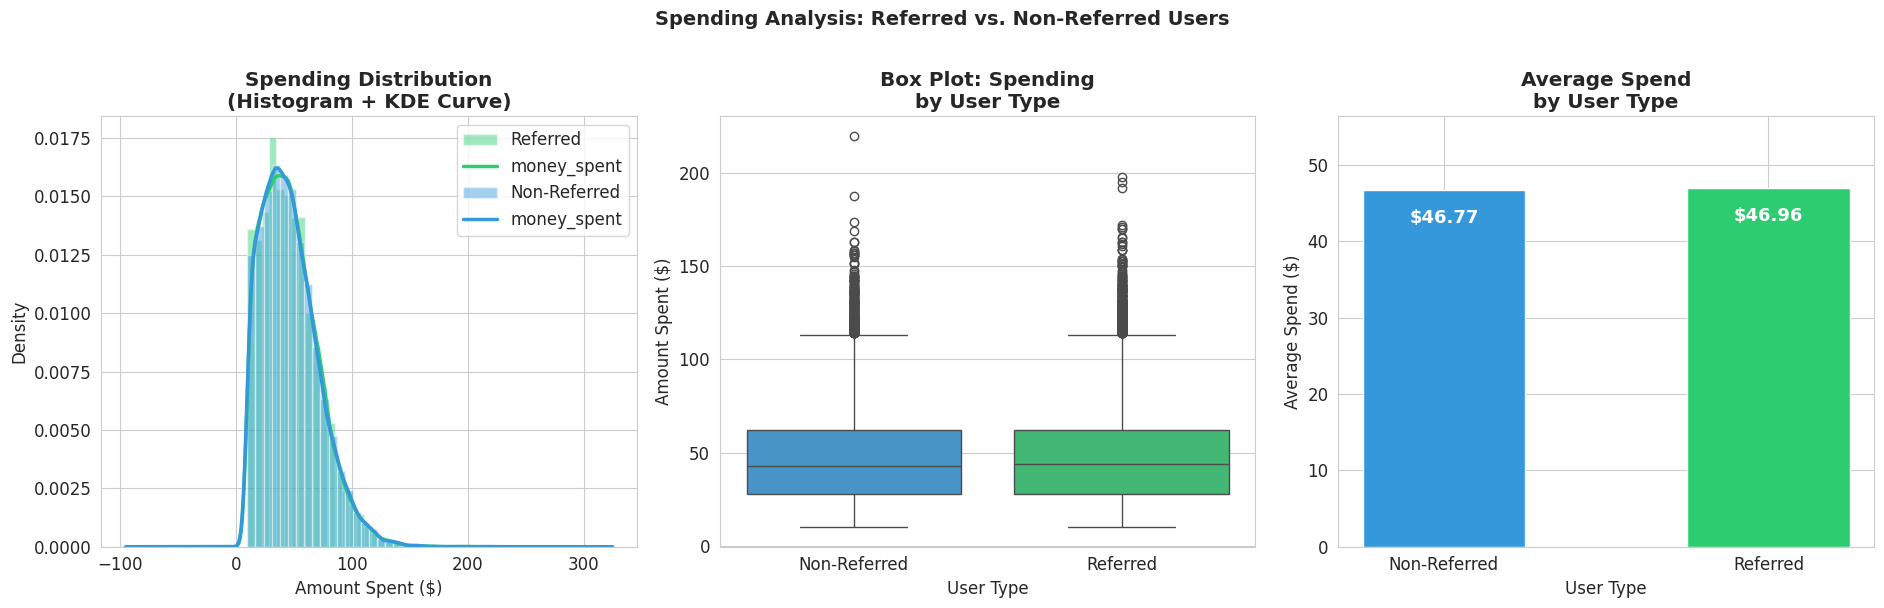

INSIGHT: Referred users spend $46.96 vs $46.77 for non-referred.
         Difference of $0.19 -- p-value = 0.3863


In [13]:
# Visualize spending distributions using three different chart types
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# CHART 1: Overlapping histograms with KDE curves
# A histogram shows how many values fall into each bin (range)
# KDE (Kernel Density Estimate) is a smooth curve version of the histogram
# density=True normalizes the histogram so the total area equals 1,
# making the two groups directly comparable even if they have different counts
for label, color in [('Referred', COLORS['referral']), ('Non-Referred', COLORS['non_referral'])]:
    subset = post[post['referral_label'] == label]['money_spent']
    axes[0].hist(subset, bins=30, alpha=0.45, color=color, label=label, density=True)
    subset.plot.kde(ax=axes[0], color=color, linewidth=2.5)  # smooth density curve

axes[0].set_title('Spending Distribution\n(Histogram + KDE Curve)', fontweight='bold')
axes[0].set_xlabel('Amount Spent ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# CHART 2: Box plots
# A box plot shows: median (middle line), IQR box (25th-75th percentile),
# whiskers (range excluding outliers), and individual dots (outliers)
# Great for comparing distribution shapes side by side
sns.boxplot(
    data=post,
    x='referral_label',
    y='money_spent',
    palette={'Referred': COLORS['referral'], 'Non-Referred': COLORS['non_referral']},
    ax=axes[1]
)
axes[1].set_title('Box Plot: Spending\nby User Type', fontweight='bold')
axes[1].set_xlabel('User Type')
axes[1].set_ylabel('Amount Spent ($)')

# CHART 3: Average spending bar chart
avg_sp = post.groupby('referral_label')['money_spent'].mean()
bar_colors = [COLORS['referral'] if l == 'Referred' else COLORS['non_referral'] for l in avg_sp.index]
bars = axes[2].bar(avg_sp.index, avg_sp.values, color=bar_colors, width=0.5, edgecolor='white')

# Annotate each bar with a dollar value label
for bar, val in zip(bars, avg_sp.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 2.5,
                 f'${val:.2f}', ha='center', va='top', fontweight='bold', color='white', fontsize=13)

axes[2].set_title('Average Spend\nby User Type', fontweight='bold')
axes[2].set_xlabel('User Type')
axes[2].set_ylabel('Average Spend ($)')
axes[2].set_ylim(0, avg_sp.max() * 1.2)

plt.suptitle('Spending Analysis: Referred vs. Non-Referred Users', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart3_spending.png', dpi=150, bbox_inches='tight')
plt.show()

diff = avg_sp['Referred'] - avg_sp['Non-Referred']
print(f'INSIGHT: Referred users spend ${avg_sp["Referred"]:.2f} vs ${avg_sp["Non-Referred"]:.2f} for non-referred.')
print(f'         Difference of ${diff:.2f} -- p-value = {p_value:.4f}')

---
## 🌍 ANALYSIS 4: Geographic Breakdown

**Question: Which countries are driving the most referral activity?**

In [14]:
# Map 2-letter country codes to full country names
country_names = {
    'US': 'United States', 'UK': 'United Kingdom', 'FR': 'France',
    'DE': 'Germany',       'IT': 'Italy',           'ES': 'Spain',
    'CA': 'Canada',        'MX': 'Mexico',          'CH': 'Switzerland'
}

# Build country-level summary for post-launch period only
country_df = post.groupby('country').agg(
    total_transactions = ('user_id',     'count'),
    referral_txns      = ('is_referral', 'sum'),   # sum of 1s = count of referral transactions
    total_revenue      = ('money_spent', 'sum'),
    avg_spend          = ('money_spent', 'mean'),
    unique_users       = ('user_id',     'nunique')
).reset_index()

# Add derived metrics
country_df['referral_rate_%'] = (country_df['referral_txns'] / country_df['total_transactions'] * 100).round(1)
country_df['country_name']    = country_df['country'].map(country_names)  # replace codes with full names
country_df['avg_spend']       = country_df['avg_spend'].round(2)

# Sort by total referral transactions (highest first)
country_df = country_df.sort_values('referral_txns', ascending=False)

print('Country Analysis -- Post-Launch:')
print(country_df[['country_name', 'total_transactions', 'referral_txns',
                   'referral_rate_%', 'avg_spend', 'total_revenue']].to_string(index=False))

Country Analysis -- Post-Launch:
  country_name  total_transactions  referral_txns  referral_rate_%  avg_spend  total_revenue
        France                8560           4748             55.5      44.60         381780
United Kingdom                8093           4588             56.7      49.12         397500
 United States                7376           4135             56.1      49.64         366169
         Italy                6382           3582             56.1      44.72         285416
         Spain                5446           3062             56.2      44.53         242496
       Germany                4593           2578             56.1      48.85         224391
        Mexico                4592           2539             55.3      42.89         196930
        Canada                4480           2506             55.9      49.25         220652
   Switzerland                 478            279             58.4      59.98          28669


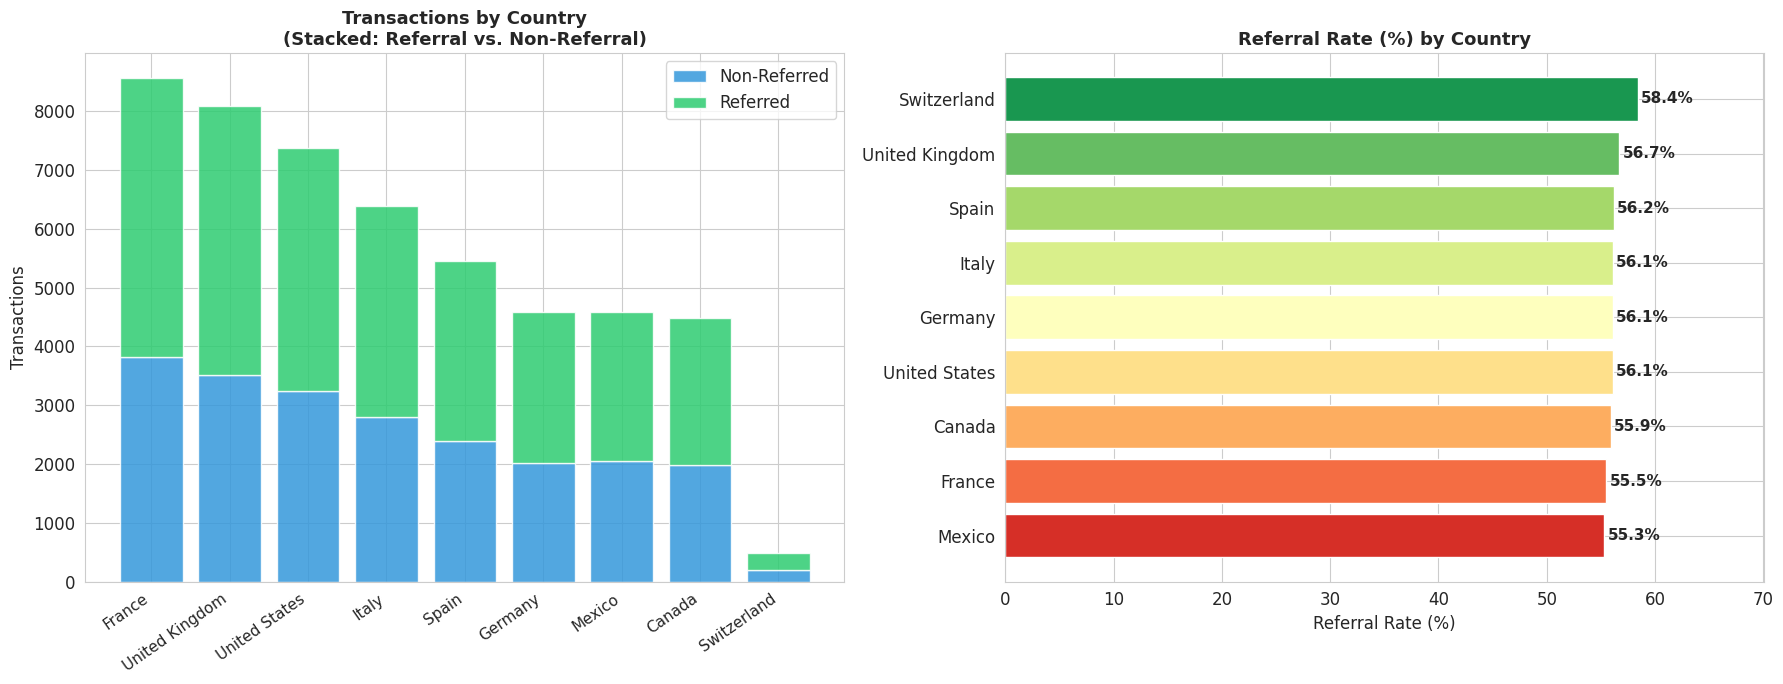

INSIGHT: France has the most referral transactions (4,748).
         All countries show a nearly identical referral rate of ~55-58%,
         suggesting the program was rolled out uniformly across all markets.


In [15]:
# Visualize geographic analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# LEFT: Stacked bar chart -- referral vs. non-referral per country
# .bar() with a 'bottom' argument stacks the second set of bars on top of the first
countries = country_df['country_name']
non_ref   = country_df['total_transactions'] - country_df['referral_txns']
ref_txns  = country_df['referral_txns']
x = range(len(countries))

ax1.bar(x, non_ref,  label='Non-Referred', color=COLORS['non_referral'], alpha=0.85)
ax1.bar(x, ref_txns, label='Referred',     color=COLORS['referral'],     alpha=0.85, bottom=non_ref)

ax1.set_xticks(x)
ax1.set_xticklabels(countries, rotation=35, ha='right', fontsize=11)
ax1.set_title('Transactions by Country\n(Stacked: Referral vs. Non-Referral)', fontweight='bold', fontsize=13)
ax1.set_ylabel('Transactions')
ax1.legend()

# RIGHT: Horizontal bar chart -- referral rate % per country (sorted)
# .sort_values() sorts rows ascending so the highest rate appears at the top of the chart
sorted_c = country_df.sort_values('referral_rate_%')

# Use a Red-Yellow-Green color gradient (low = red, high = green)
bar_colors_c = sns.color_palette('RdYlGn', len(sorted_c))
hbars = ax2.barh(sorted_c['country_name'], sorted_c['referral_rate_%'],
                 color=bar_colors_c, edgecolor='white')

# Annotate each bar with its % value
for bar in hbars:
    width = bar.get_width()
    ax2.text(width + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{width:.1f}%', va='center', fontweight='bold', fontsize=11)

ax2.set_title('Referral Rate (%) by Country', fontweight='bold', fontsize=13)
ax2.set_xlabel('Referral Rate (%)')
ax2.set_xlim(0, sorted_c['referral_rate_%'].max() * 1.2)

plt.tight_layout()
plt.savefig('chart4_geographic.png', dpi=150, bbox_inches='tight')
plt.show()

top = country_df.iloc[0]
print(f'INSIGHT: {top["country_name"]} has the most referral transactions ({int(top["referral_txns"]):,}).')
print(f'         All countries show a nearly identical referral rate of ~55-58%,')
print(f'         suggesting the program was rolled out uniformly across all markets.')

---
## 📋 ANALYSIS 5: Full Before vs. After Comparison Table

In [16]:
# Build a comprehensive before/after comparison table
before_df = df[df['period'] == 'Before Program']
after_df  = df[df['period'] == 'After Program']

# Count distinct days in each period (used to calculate per-day averages)
before_days = before_df['date'].nunique()
after_days  = after_df['date'].nunique()

# Dictionary of metrics: each entry maps name -> (before_value, after_value)
metrics = {
    'Total Transactions'            : (len(before_df),                              len(after_df)),
    'Avg Transactions / Day'        : (len(before_df) / before_days,               len(after_df) / after_days),
    'Unique Users'                  : (before_df['user_id'].nunique(),              after_df['user_id'].nunique()),
    'Total Revenue ($)'             : (before_df['money_spent'].sum(),              after_df['money_spent'].sum()),
    'Avg Revenue / Day ($)'         : (before_df['money_spent'].sum()/before_days,  after_df['money_spent'].sum()/after_days),
    'Avg Spend per Transaction ($)' : (before_df['money_spent'].mean(),             after_df['money_spent'].mean()),
    'Median Spend ($)'              : (before_df['money_spent'].median(),           after_df['money_spent'].median()),
}

# Build a summary DataFrame from the dictionary
summary = pd.DataFrame(metrics, index=['Before Launch', 'After Launch']).T

# Calculate % change and format it with a + or - sign
summary['% Change'] = ((summary['After Launch'] - summary['Before Launch']) / summary['Before Launch'] * 100).round(1)
summary['% Change'] = summary['% Change'].apply(lambda x: f'+{x:.1f}%' if x > 0 else f'{x:.1f}%')

summary['Before Launch'] = summary['Before Launch'].round(1)
summary['After Launch']  = summary['After Launch'].round(1)

print('=' * 65)
print('BEFORE vs. AFTER PROGRAM LAUNCH -- KEY METRICS')
print('=' * 65)
print(summary.to_string())
print(f'\nNote: Before = Oct 3-30 ({before_days} days). After = Oct 31-Nov 27 ({after_days} days).')

BEFORE vs. AFTER PROGRAM LAUNCH -- KEY METRICS
                               Before Launch  After Launch % Change
Total Transactions                   47341.0       50000.0    +5.6%
Avg Transactions / Day                1690.8        1785.7    +5.6%
Unique Users                          5000.0       18397.0  +267.9%
Total Revenue ($)                  2006396.0     2344003.0   +16.8%
Avg Revenue / Day ($)                71657.0       83714.4   +16.8%
Avg Spend per Transaction ($)           42.4          46.9   +10.6%
Median Spend ($)                        40.0          44.0   +10.0%

Note: Before = Oct 3-30 (28 days). After = Oct 31-Nov 27 (28 days).


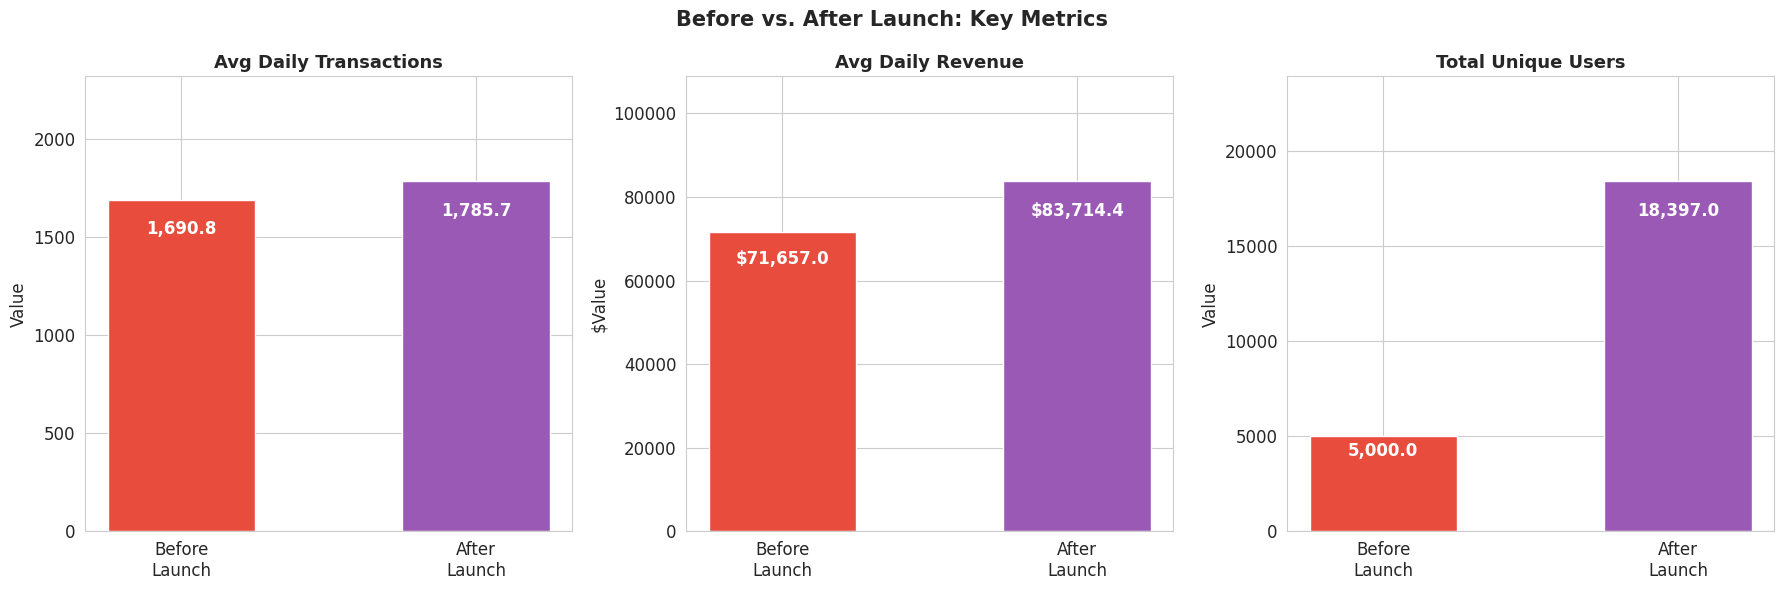

In [17]:
# Bar chart comparison for 3 headline metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

raw_metrics = {
    'Avg Transactions / Day' : (len(before_df)/before_days,                      len(after_df)/after_days),
    'Avg Revenue / Day ($)'  : (before_df['money_spent'].sum()/before_days,       after_df['money_spent'].sum()/after_days),
    'Unique Users'           : (float(before_df['user_id'].nunique()),             float(after_df['user_id'].nunique())),
}

plot_labels = {
    'Avg Transactions / Day' : ('Avg Daily Transactions', ''),
    'Avg Revenue / Day ($)'  : ('Avg Daily Revenue', '$'),
    'Unique Users'           : ('Total Unique Users', ''),
}

for ax, (key, (title, prefix)) in zip(axes, plot_labels.items()):
    before_val, after_val = raw_metrics[key]
    bars = ax.bar(['Before\nLaunch', 'After\nLaunch'],
                  [before_val, after_val],
                  color=[COLORS['before'], COLORS['after']],
                  width=0.5, edgecolor='white')
    # Add value labels inside the bars
    for bar, val in zip(bars, [before_val, after_val]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 0.94,
                f'{prefix}{val:,.1f}', ha='center', va='top',
                fontweight='bold', color='white', fontsize=12)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylabel(f'{prefix}Value')
    ax.set_ylim(0, max(before_val, after_val) * 1.3)

plt.suptitle('Before vs. After Launch: Key Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🖥️ ANALYSIS 6: Executive Dashboard

All six key charts in one figure -- ready to present to management.

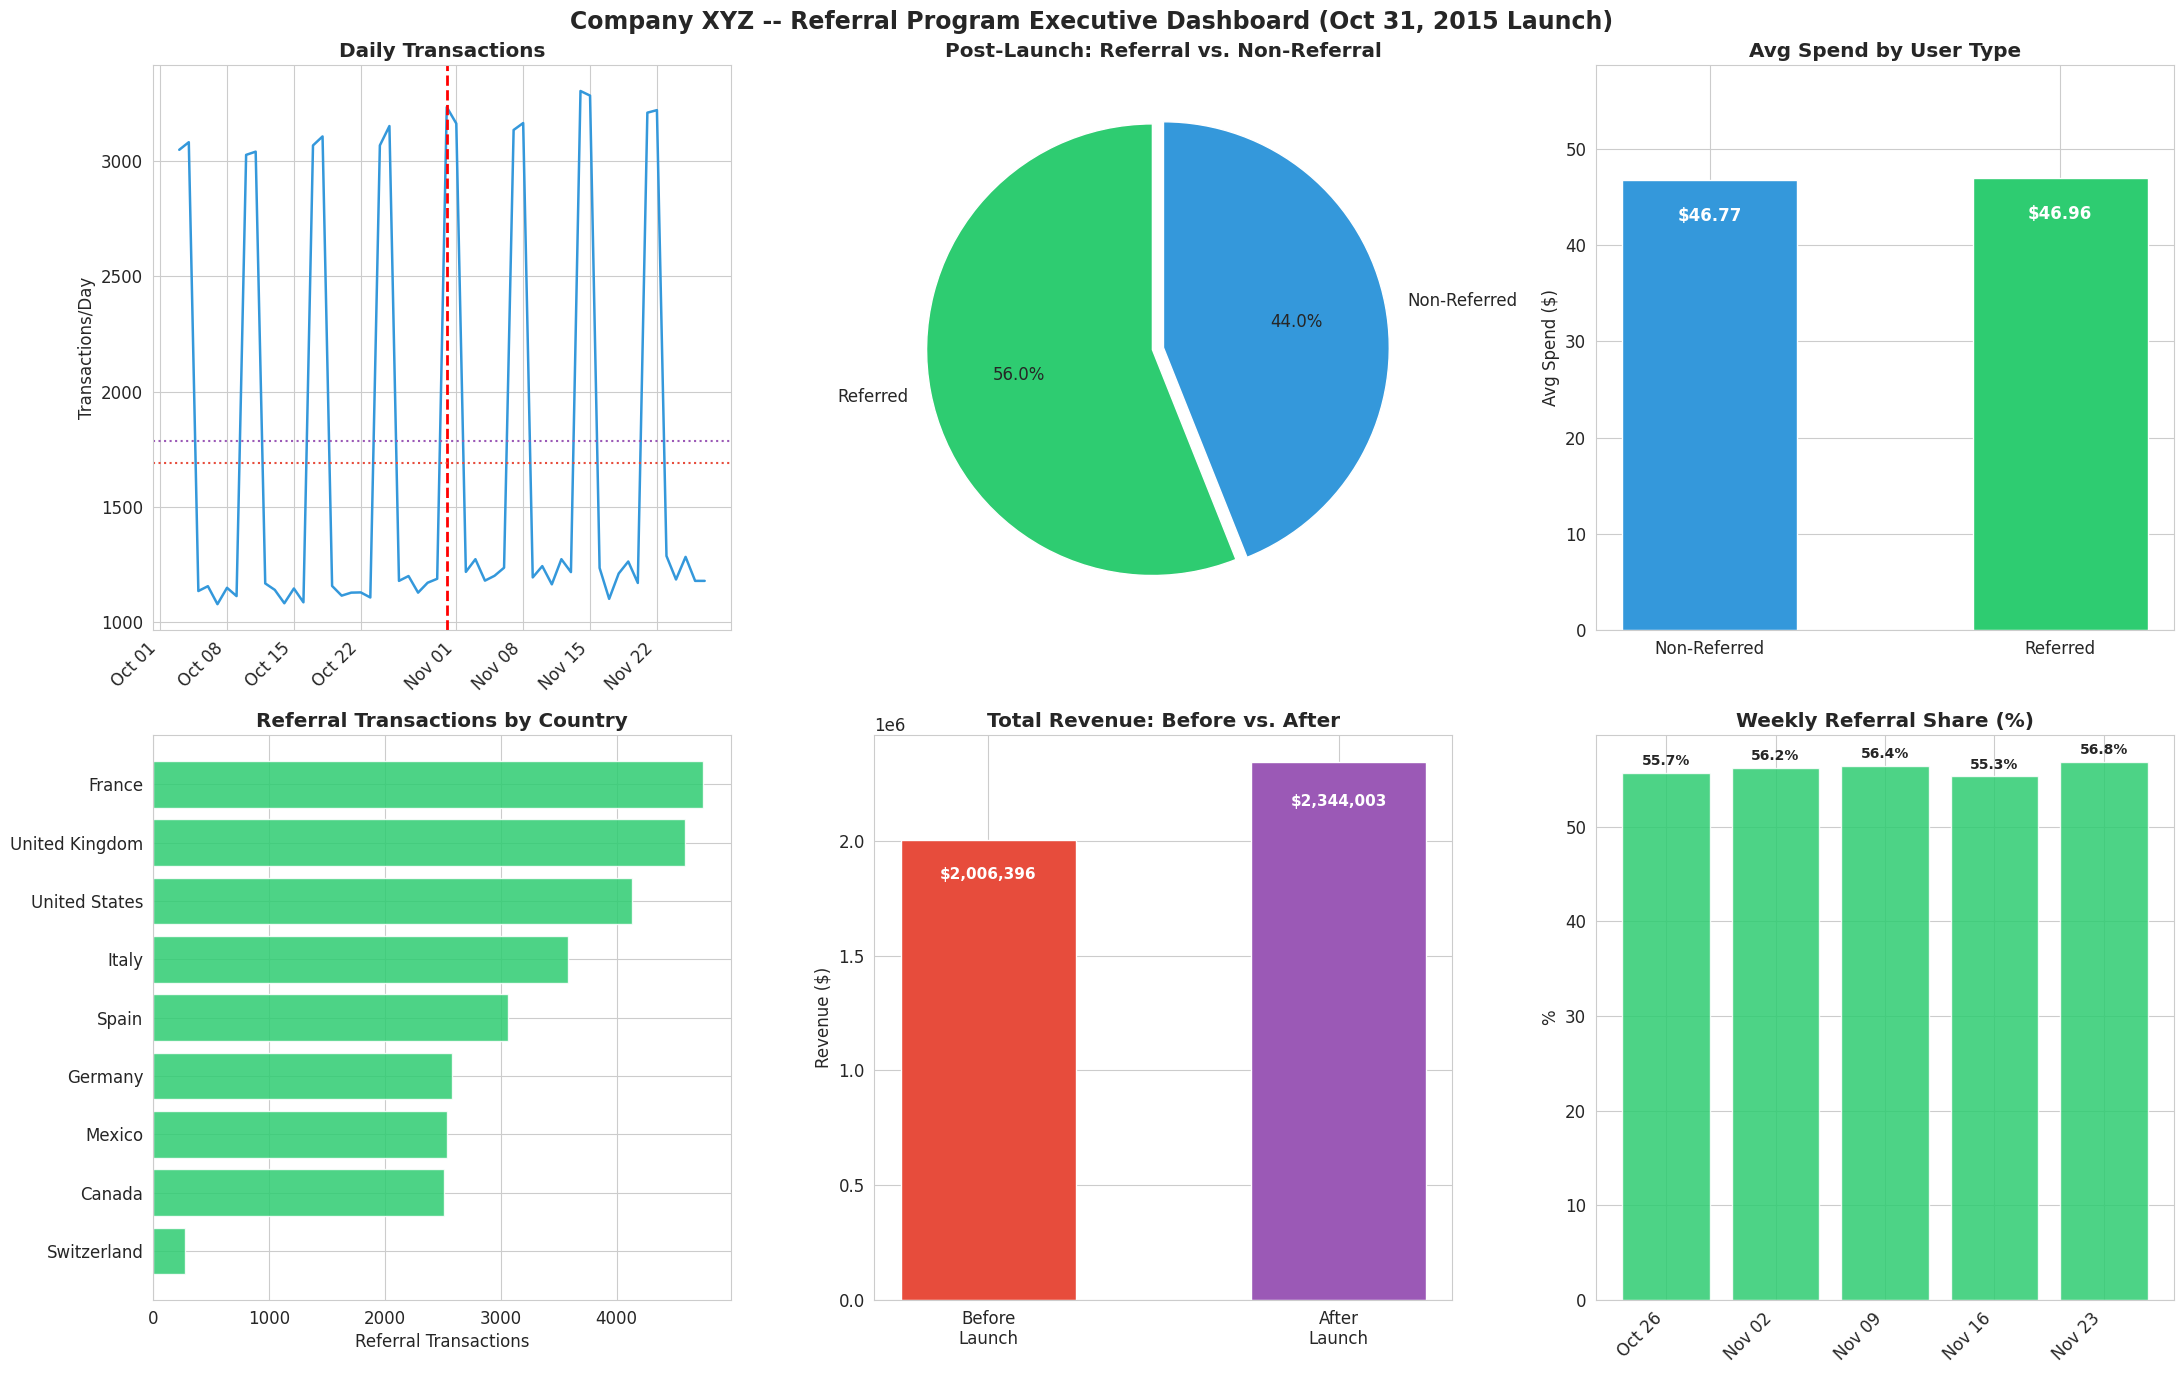

Executive dashboard saved as chart6_executive_dashboard.png


In [18]:
fig = plt.figure(figsize=(22, 14))
fig.suptitle('Company XYZ -- Referral Program Executive Dashboard (Oct 31, 2015 Launch)',
             fontsize=17, fontweight='bold', y=0.98)

# Panel 1 (top-left): Daily Transaction Trend
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(daily['date'], daily['transactions'], color='#3498db', linewidth=1.8)
ax1.axvline(x=LAUNCH_DATE, color='red', linestyle='--', linewidth=2)
ax1.axhline(y=avg_txn_before, color=COLORS['before'], linestyle=':', linewidth=1.5)
ax1.axhline(y=avg_txn_after,  color=COLORS['after'],  linestyle=':', linewidth=1.5)
ax1.set_title('Daily Transactions', fontweight='bold')
ax1.set_ylabel('Transactions/Day')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Panel 2 (top-center): Referral Share Pie
ax2 = fig.add_subplot(2, 3, 2)
ax2.pie(ref_counts.values, labels=ref_counts.index,
        autopct='%1.1f%%',
        colors=[COLORS['referral'], COLORS['non_referral']],
        startangle=90, explode=(0.05, 0), textprops={'fontsize': 12})
ax2.set_title('Post-Launch: Referral vs. Non-Referral', fontweight='bold')

# Panel 3 (top-right): Avg Spend by User Type
ax3 = fig.add_subplot(2, 3, 3)
avg_sp2 = post.groupby('referral_label')['money_spent'].mean()
bar_c3  = [COLORS['referral'] if l == 'Referred' else COLORS['non_referral'] for l in avg_sp2.index]
bars3   = ax3.bar(avg_sp2.index, avg_sp2.values, color=bar_c3, width=0.5, edgecolor='white')
for b, v in zip(bars3, avg_sp2.values):
    ax3.text(b.get_x()+b.get_width()/2, b.get_height()*0.94,
             f'${v:.2f}', ha='center', va='top', color='white', fontweight='bold', fontsize=12)
ax3.set_title('Avg Spend by User Type', fontweight='bold')
ax3.set_ylabel('Avg Spend ($)')
ax3.set_ylim(0, avg_sp2.max() * 1.25)

# Panel 4 (bottom-left): Referral Volume by Country
ax4 = fig.add_subplot(2, 3, 4)
c_sorted = country_df.sort_values('referral_txns', ascending=True)
ax4.barh(c_sorted['country_name'], c_sorted['referral_txns'], color=COLORS['referral'], alpha=0.85)
ax4.set_title('Referral Transactions by Country', fontweight='bold')
ax4.set_xlabel('Referral Transactions')

# Panel 5 (bottom-center): Revenue Before vs. After
ax5 = fig.add_subplot(2, 3, 5)
rev_vals = [before_df['money_spent'].sum(), after_df['money_spent'].sum()]
rev_bars = ax5.bar(['Before\nLaunch', 'After\nLaunch'], rev_vals,
                   color=[COLORS['before'], COLORS['after']], width=0.5, edgecolor='white')
for b, v in zip(rev_bars, rev_vals):
    ax5.text(b.get_x()+b.get_width()/2, b.get_height()*0.94,
             f'${v:,.0f}', ha='center', va='top', color='white', fontweight='bold', fontsize=11)
ax5.set_title('Total Revenue: Before vs. After', fontweight='bold')
ax5.set_ylabel('Revenue ($)')

# Panel 6 (bottom-right): Weekly Referral Share
ax6 = fig.add_subplot(2, 3, 6)
bars6 = ax6.bar(range(len(weekly_piv)), weekly_piv['referral_share_pct'],
                color=COLORS['referral'], alpha=0.85, edgecolor='white')
for b in bars6:
    ax6.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
             f'{b.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax6.set_xticks(range(len(weekly_piv)))
ax6.set_xticklabels([w.strftime('%b %d') for w in weekly_piv.index], rotation=45, ha='right')
ax6.set_title('Weekly Referral Share (%)', fontweight='bold')
ax6.set_ylabel('%')

plt.tight_layout()
plt.savefig('chart6_executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Executive dashboard saved as chart6_executive_dashboard.png')

---
## ⚠️ ANALYSIS 7: Limitations & Risks

In [19]:
print("""
ANALYSIS LIMITATIONS AND RISKS
================================

1. NO CONTROL GROUP -- The Biggest Risk
   The program launched to ALL users simultaneously.
   We cannot definitively prove the program caused the growth.
   Other possible explanations:
     - November seasonal/holiday shopping trends
     - Concurrent marketing campaigns running at the same time
     - Natural organic growth unrelated to the program

2. ATTRIBUTION BIAS
   Some users labeled 'Referred' (is_referral = 1) may have
   found the platform on their own but still used a referral
   code to claim the $10 benefit -- inflating the referral count.

3. SHORT OBSERVATION WINDOW (~28 days post-launch)
   - Cannot yet assess long-term retention of referred users
   - Cannot calculate Lifetime Value (LTV) of referred users
   - Initial excitement may not represent steady-state performance

4. SELF-REFERRAL FRAUD RISK
   Users could create fake accounts to earn the $10 credit
   repeatedly. This would inflate costs and distort the data.
   Anti-fraud analysis (e.g., flagging device reuse across
   accounts) is recommended.

RECOMMENDED: A/B TEST DESIGN
==============================

   For the NEXT program iteration, implement a proper A/B test:

   GROUP A (Test):    50% of users --> receive the referral program
   GROUP B (Control): 50% of users --> do NOT receive the program

   Randomly assign users to groups BEFORE launch.
   Compare outcomes between groups after 4-8 weeks.

   This isolates the program's true causal effect by eliminating
   all confounding variables such as seasonality and other campaigns.
""")


ANALYSIS LIMITATIONS AND RISKS

1. NO CONTROL GROUP -- The Biggest Risk
   The program launched to ALL users simultaneously.
   We cannot definitively prove the program caused the growth.
   Other possible explanations:
     - November seasonal/holiday shopping trends
     - Concurrent marketing campaigns running at the same time
     - Natural organic growth unrelated to the program

2. ATTRIBUTION BIAS
   Some users labeled 'Referred' (is_referral = 1) may have
   found the platform on their own but still used a referral
   code to claim the $10 benefit -- inflating the referral count.

3. SHORT OBSERVATION WINDOW (~28 days post-launch)
   - Cannot yet assess long-term retention of referred users
   - Cannot calculate Lifetime Value (LTV) of referred users
   - Initial excitement may not represent steady-state performance

4. SELF-REFERRAL FRAUD RISK
   Users could create fake accounts to earn the $10 credit
   repeatedly. This would inflate costs and distort the data.
   Anti-fraud

---
## 💡 FINAL: Insights & Recommendations

In [20]:
# Gather final numbers for the summary printout
n_ref     = int(post['is_referral'].sum())
ref_rev   = post[post['is_referral']==1]['money_spent'].sum()
cred_cost = n_ref * 10
net_rev   = ref_rev - cred_cost
ref_share = n_ref / len(post) * 100
ref_avg   = post[post['is_referral']==1]['money_spent'].mean()
nref_avg  = post[post['is_referral']==0]['money_spent'].mean()

print(f"""
KEY FINDINGS
=============

FINDING 1 -- USER GROWTH
  Daily transactions grew from {avg_txn_before:.0f} to {avg_txn_after:.0f}/day ({txn_growth:+.1f}%) after launch.
  Unique daily users jumped by {user_growth:+.1f}%. The program coincides with
  a significant increase in platform activity.

FINDING 2 -- REFERRAL SCALE
  {ref_share:.1f}% of all post-launch transactions ({n_ref:,} out of {len(post):,})
  came through the referral program in just 28 days.

FINDING 3 -- SPENDING BEHAVIOR
  Referred users:  ${ref_avg:.2f} average spend
  Non-referred:    ${nref_avg:.2f} average spend
  Difference: ${ref_avg - nref_avg:.2f} -- p-value = {p_value:.4f}
  {'Result: STATISTICALLY SIGNIFICANT' if p_value < 0.05 else 'Result: NOT statistically significant'}

FINDING 4 -- PROGRAM ROI
  Gross revenue from referred users:  ${ref_rev:>12,.2f}
  Credit costs ($10 x {n_ref:,}):   ${cred_cost:>12,.2f}
  Net revenue from referrals:         ${net_rev:>12,.2f}
  The program is generating positive net revenue.

FINDING 5 -- GEOGRAPHY
  All 9 countries show a nearly identical referral rate of 55-58%.
  France leads in total referral volume ({int(country_df.iloc[0]['referral_txns']):,} transactions).
  Switzerland has the highest avg spend per transaction.

NEXT STEPS
===========

  1. RUN AN A/B TEST next time to establish true causality.
     Split new users 50/50 before the next program launch.

  2. TRACK RETENTION over 3-6 months.
     If referred users return for repeat purchases, increase the credit.

  3. TEST DIFFERENT INCENTIVE AMOUNTS ($5 vs $10 vs $15)
     to find the optimal cost-efficiency balance.

  4. ADD FRAUD DETECTION to flag suspicious self-referral patterns
     (e.g., same device_id across multiple new accounts).

  5. DOUBLE-SIDED INCENTIVE: also reward the new referred user
     (e.g., $5 off their first purchase) to increase conversion.

  6. EXPAND TOP MARKETS: France and UK lead in volume;
     targeted campaigns there could amplify the effect further.
""")


KEY FINDINGS

FINDING 1 -- USER GROWTH
  Daily transactions grew from 1691 to 1786/day (+5.6%) after launch.
  Unique daily users jumped by +21.8%. The program coincides with
  a significant increase in platform activity.

FINDING 2 -- REFERRAL SCALE
  56.0% of all post-launch transactions (28,017 out of 50,000)
  came through the referral program in just 28 days.

FINDING 3 -- SPENDING BEHAVIOR
  Referred users:  $46.96 average spend
  Non-referred:    $46.77 average spend
  Difference: $0.19 -- p-value = 0.3863
  Result: NOT statistically significant

FINDING 4 -- PROGRAM ROI
  Gross revenue from referred users:  $1,315,787.00
  Credit costs ($10 x 28,017):   $  280,170.00
  Net revenue from referrals:         $1,035,617.00
  The program is generating positive net revenue.

FINDING 5 -- GEOGRAPHY
  All 9 countries show a nearly identical referral rate of 55-58%.
  France leads in total referral volume (4,748 transactions).
  Switzerland has the highest avg spend per transaction.

NE

---

## 🎓 Python Concepts You Learned in This Notebook

| Concept | Where We Used It |
|---|---|
| `pd.read_csv()` | Loading data from a real CSV file |
| `pd.to_datetime()` | Converting text dates to real date objects |
| `df.head()`, `.shape`, `.dtypes`, `.describe()` | Exploratory Data Analysis |
| `df.isnull().sum()` | Detecting missing values |
| Boolean indexing: `df[df['col'] == value]` | Filtering rows by condition |
| `df.groupby().agg()` | Summarizing data by groups |
| `np.where()` | Conditional column creation (Python IF) |
| `.map()` | Replacing values using a dictionary |
| `.value_counts()` | Counting occurrences of each value |
| `.pivot()` | Reshaping from long to wide format |
| `matplotlib` + `seaborn` | Charts: line, bar, pie, box plot, histogram, KDE |
| `scipy.stats.ttest_ind()` | Independent t-test for statistical significance |
| Before/After comparison | Measuring program impact |
| A/B test framing | Best practice for causal inference |

---
**Tip:** Run cells top to bottom using `Shift + Enter`. If you get an error, re-run Step 1 (install) and Step 2 (import) first, then retry the failing cell.